# Solution: Les statistiques multivariées avec Pandas

On utilise le dataset `mtcars` qui comprend 32 observations sur 11 variables : 

0. **mpg** Miles/(US) gallon
0. **cyl** Number of cylinders
0. **disp** Displacement (cu.in.)
0. **hp** Gross horsepower
0. **drat** Rear axle ratio
0. **wt** Weight (1000 lbs)
0. **qsec** 1/4 mile time
0. **vs** Engine (0 = V-shaped, 1 = straight)
0. **am** Transmission (0 = automatic, 1 = manual)
0. **gear** Number of forward gears
0. **carb** Number of carburators


In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from matplotlib import rcParams
rcParams['figure.figsize'] = 8, 4
sns.set_style('whitegrid')

In [2]:
cars = pd.read_csv("../../data/mtcars.csv")
cars

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


## Relation entre variables qualitatives et variables numériques

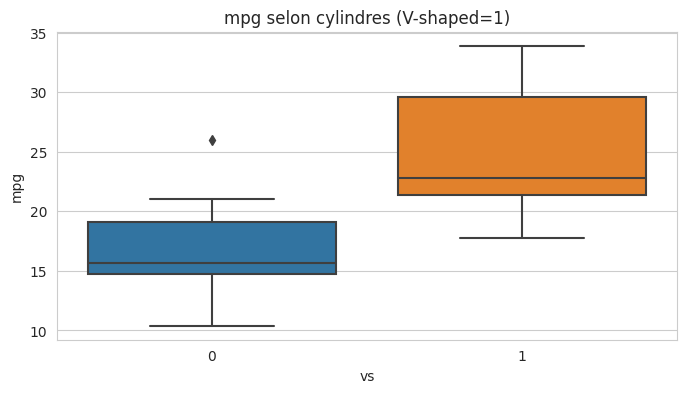

In [3]:
# TODO: Representer la consommation y=mpg en fonction de la disposition des cylindres x=vs

ax = sns.boxplot(data=cars, x="vs", y="mpg")
ax.set_title("mpg selon cylindres (V-shaped=1)");

## Recherche de corrélations entre variables

Un coefficient de corrélation est une valeur numérique calculée à partir de deux séries de valeurs dont on souhaite évaluer la corrélation. Il calcule dans quelle mesure deux variables tendent à changer ensemble.

Il peut être intéressant d'avoir des variables:

- corrélées avec la variable cible (target)
- peu corrélées entre elles, ce qui pourrait signifier de la redondance et qui peut être problématique pour certains algorithmes

On peut avoir une intuition de cette correlation dans une représentation d'une variable par rapport à une autre (scatterplot).

La [fonction `pairplot`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) de seaborn permet d'obtenir une vue synthétique de ces représentations

- En abscisse et en ordonnée : les variables du dataframe
- A l'intersection : le nuage de points (scatterplot) correspondant
- Histogramme sur la diagonale 
- Attention aux temps de calcul !


In [4]:
# Sélectionner les variables numériques continues de cars

cars_num_cont = cars.drop(columns=['model', 'cyl', 'vs', 'am', 'gear', 'carb'])

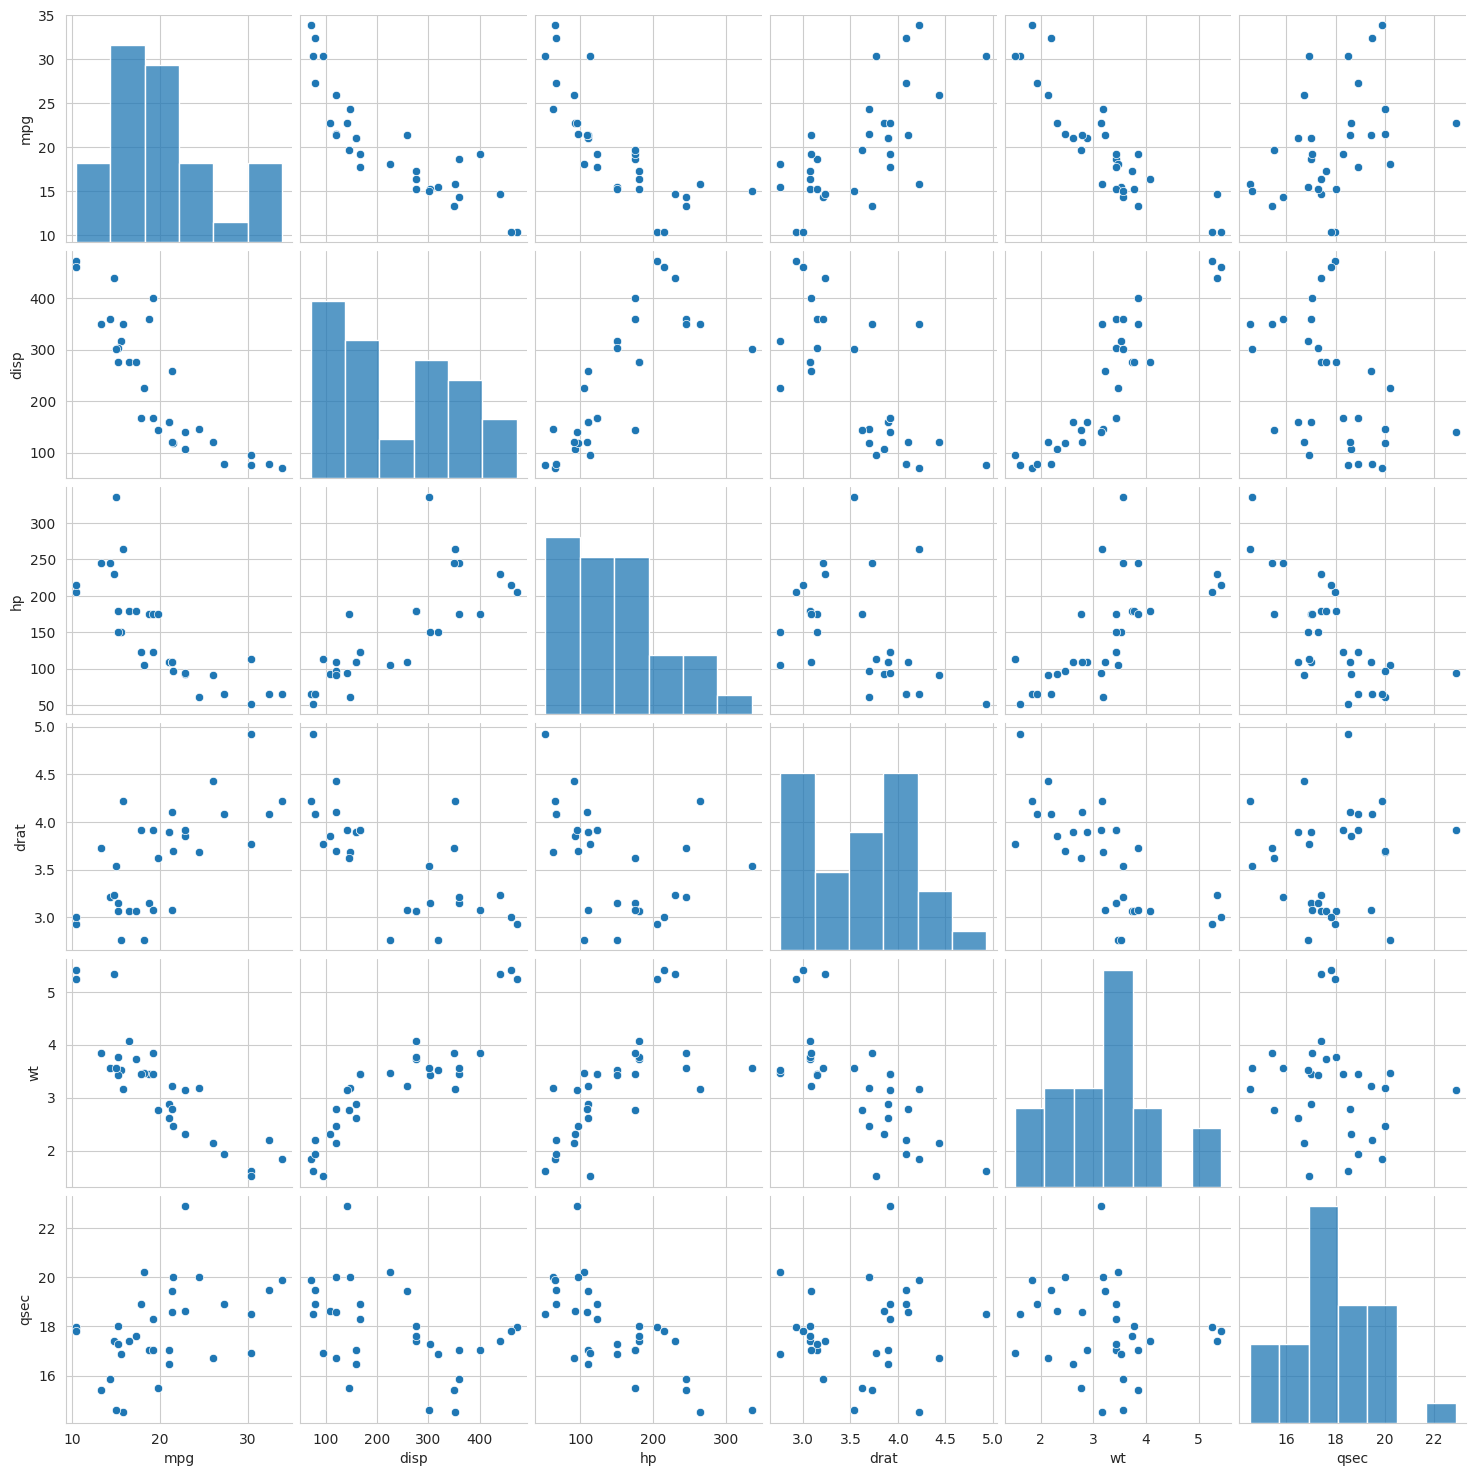

In [5]:
# Afficher des nuages de points entre paires de variables continues 

sns.pairplot(cars_num_cont);

## Coefficient de corrélation de Pearson (correlation linéaire)

voir la [documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html)

In [11]:
# TODO: Calculer le coefficient de Pearson des variables du DataFrame cars (cars.corr(...))

corr_pearson = cars_num_cont.corr(method="pearson", numeric_only=True)
corr_pearson

,mpg,disp,hp,drat,wt,qsec
mpg,1.000000,-0.847551,-0.776168,0.681172,-0.867659,0.418684
disp,-0.847551,1.000000,0.790949,-0.710214,0.887980,-0.433698
hp,-0.776168,0.790949,1.000000,-0.448759,0.658748,-0.708223
drat,0.681172,-0.710214,-0.448759,1.000000,-0.712441,0.091205
wt,-0.867659,0.887980,0.658748,-0.712441,1.000000,-0.174716
qsec,0.418684,-0.433698,-0.708223,0.091205,-0.174716,1.000000


<AxesSubplot: >

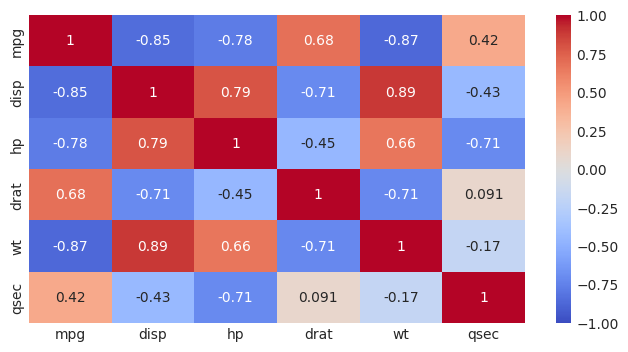

In [81]:
# TODO: Visualiser la matrice de corrélation de Pearson avec seaborn (sns.heatmap)

sns.heatmap(corr_pearson, vmin=-1, vmax=1, annot=True, cmap="coolwarm")

### Corrélation de Spearman

Dans le cas de Spearman, nous ne nous limitons plus à une relation linéaire entre deux variables, par contre la relation doit être **monotone** (strictement croissante ou décroissante). 

Dans une relation monotone, les variables ont tendance à changer ensemble, mais pas forcément à une vitesse constante.

Spearman s'applique entre **deux variables continues ou ordinales**.

Le coefficient a une valeur comprise entre [-1,1].

### Calculer la matrice de correlation de Spearman avec Pandas

In [82]:
# TODO: Sélectionner toutes les variables numériques de cars

cars_num = cars.drop(columns=['model', 'vs', 'am'])

In [84]:
# TODO: Calculez la matrice de corrélation des variables du dataframe cars

corr_spearman = cars_num.corr(method='spearman', numeric_only=True)
corr_spearman

,mpg,cyl,disp,hp,drat,wt,qsec,gear,carb
mpg,1.000000,-0.910801,-0.908882,-0.894665,0.651455,-0.886422,0.466936,0.542782,-0.657498
cyl,-0.910801,1.000000,0.927652,0.901791,-0.678881,0.857728,-0.572351,-0.564310,0.580068
disp,-0.908882,0.927652,1.000000,0.851043,-0.683592,0.897706,-0.459782,-0.594470,0.539778
hp,-0.894665,0.901791,0.851043,1.000000,-0.520125,0.774677,-0.666606,-0.331402,0.733379
drat,0.651455,-0.678881,-0.683592,-0.520125,1.000000,-0.750390,0.091869,0.744816,-0.125223
wt,-0.886422,0.857728,0.897706,0.774677,-0.750390,1.000000,-0.225401,-0.676128,0.499812
qsec,0.466936,-0.572351,-0.459782,-0.666606,0.091869,-0.225401,1.000000,-0.148200,-0.658718
gear,0.542782,-0.564310,-0.594470,-0.331402,0.744816,-0.676128,-0.148200,1.000000,0.114887
carb,-0.657498,0.580068,0.539778,0.733379,-0.125223,0.499812,-0.658718,0.114887,1.000000


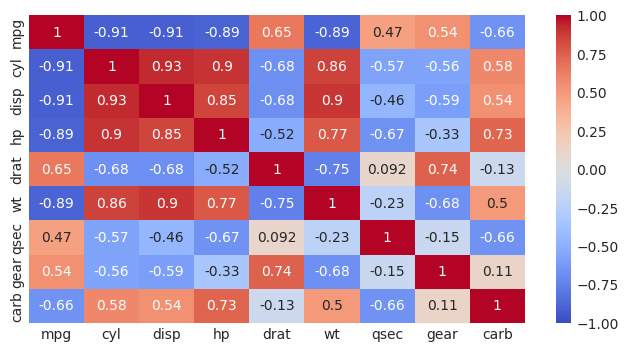

In [85]:
# TODO: Visualiser la matrice de corrélation de Spearman avec seaborn (sns.heatmap)

sns.heatmap(corr_spearman, vmin=-1, vmax=1, annot=True, cmap="coolwarm");